<a href="https://colab.research.google.com/github/gyro802b/mod-arith-grokking-llc/blob/main/Modular_Arithmetic_Grokking_Ablations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grokking Modular Addition Ablations

This notebook contains a few ablations for the base modular arithmetic notebook.

**NOTE:** Checkpoints are not persisted to disk.

### Imports and Setup

In [ ]:
%pip install devinterp nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
import random
import math
from copy import copy, deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from devinterp.optim.sgld import SGLD
from devinterp.slt.sampler import estimate_learning_coeff_with_summary
from devinterp.utils import evaluate_ce
from devinterp.utils import plot_trace

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Model Definitions

In [ ]:
@dataclass
class ExperimentParams:
    p: int = 59
    n_batches: int = 20000
    n_save_model_checkpoints: int = 100
    print_times: int = 100
    lr: float = .001
    train_frac: float = 0.6
    batch_size: int = 100
    random_seed: int = 42
    device: str = DEVICE
    weight_decay: float = .5

@dataclass
class TransformerExperimentParams(ExperimentParams):
    n_attn_heads: int = 4
    d_model: int = 128
    d_mlp: int = d_model * 4
    use_constant_attn: bool = False
    pos_embed_type: str = "learned" # oneof "const", "learned", "none"

@dataclass
class MlpExperimentParams(ExperimentParams):
    hidden_size: int = 256
    embed_dim: int = 128

@dataclass
class LlcEstimationParams:
    lr: float = 5e-6
    gamma: float = 100
    nbeta: int = 100
    num_draws: int = 500
    num_chains: int = 1
    batch_size: int = 128
    num_burnin_steps: int = 2000

class Transformer(nn.Module):
    """Expected to be able to learn 'Clock' modular addition algorithm when
    attention is not constant, and positional embeddings are not ablated.
    """
    class ConstantAttention(nn.Module):
        def __init__(self, d_model):
            super().__init__()
            max_ctx = 2 # Hardcoded for now
            self.W_v = nn.Linear(d_model, d_model, bias=False)
            self.W_o = nn.Linear(d_model, d_model, bias=False)
            self.register_buffer('attn', torch.ones(max_ctx, max_ctx) / max_ctx)

        def forward(self,q, k, v, need_weights=False):
            V = self.W_v(v)
            out = self.attn @ V
            return self.W_o(out), None



    class PosEncode(nn.Module):
        def __init__(self, d_model, pe_type):
            super().__init__()
            max_ctx = 2 # Hardcoded for now
            if pe_type == "const":
                self.register_buffer('W_pos', torch.tensor([0, 1.0])[:, None])
            else:
                self.W_pos = nn.Parameter(torch.randn(max_ctx, d_model)/math.sqrt(d_model))

        def forward(self, x):
            return x+self.W_pos[:x.shape[-2]]


    def __init__(self, params):
        super().__init__()
        self.embedding = nn.Embedding(params.p, params.d_model)
        if params.pos_embed_type == "none":
            self.pos_embed = None
        else:
            self.pos_embed = Transformer.PosEncode(params.d_model, params.pos_embed_type)

        if not params.use_constant_attn:
            self.attn = nn.MultiheadAttention(params.d_model, params.n_attn_heads, batch_first=True)
        else:
            self.attn = Transformer.ConstantAttention(params.d_model)
        # No layer norm;
        self.linear1 = nn.Linear(params.d_model, params.d_mlp)
        self.act = nn.ReLU()
        self.linear2 = nn.Linear(params.d_mlp, params.d_model)

        self.unembed = nn.Linear(params.d_model, params.p)
        self.vocab_size = params.p

    def forward(self, x, return_intermediates=False):
        e1 = self.embedding(x[..., 0])
        e2 = self.embedding(x[..., 1])
        x = torch.stack((e1, e2), dim=-2)
        if self.pos_embed:
            x = self.pos_embed(x)
        h, _ = self.attn(x, x, x, need_weights=False)
        x = x + h
        x = x + self.linear2(self.act(self.linear1(x)))

        x = self.unembed(x)
        if len(x.shape) > 2:
            x = x[...,-1,:]
        else:
            x = x[-1,:]
        if not return_intermediates:
            return x
        return x, e1, e2

class MLP(nn.Module):
    """Expected to learn 'Pizza' modular addition algorithm
    """
    def __init__(self, params):
        super().__init__()
        self.embedding = nn.Embedding(params.p, params.embed_dim)
        self.linear1r = nn.Linear(params.embed_dim, params.hidden_size, bias=True)
        self.linear1l = nn.Linear(params.embed_dim, params.hidden_size, bias=True)
        self.linear2 = nn.Linear(params.hidden_size, params.p, bias=False)
        self.act = nn.ReLU()
        self.vocab_size = params.p

    def forward(self, x, return_intermediates=False):
        e1 = self.embedding(x[..., 0])
        e2 = self.embedding(x[..., 1])
        x1 = self.linear1l(e1)
        x2 = self.linear1r(e2)
        x = x1 + x2
        x = self.act(x)
        x = self.linear2(x)
        if not return_intermediates:
            return x
        return x, e1, e2

def grad_pair(model, dataset, device, n_samples=100):
    """Since `(a+b)%p == (b+a)%p`, we can check sensitivity to argument ordering
    by comparing the behavior with input x1=[a,b] and x2=[b,a]

    If Ea(x1) and Eb(x2) have similar gradients, this may imply input symmetry
    """
    model.eval()
    p = model.vocab_size
    # Random (a, b, c) including wrong classes
    xs = [(a, b) for a in range(p) for b in range(p)]
    random.shuffle(xs)
    xs = xs[:n_samples]

    total = 0.0
    for a, b in xs:
        c = (a+b)%p
        x1 = torch.tensor([[a, b]], device=device)
        x2 = torch.tensor([[b, a]], device=device)
        q1, ea1, eb1 = model(x1, return_intermediates=True)
        q2, ea2, eb2 = model(x2, return_intermediates=True)
        ga1, gb1 = torch.autograd.grad(q1[0, c], (ea1, eb1))
        ga2, gb2 = torch.autograd.grad(q2[0, c], (ea2, eb2))
        total += F.cosine_similarity(ga1, gb2).item() + F.cosine_similarity(gb1, ga2).item()

    return total / (n_samples * 2)

def grad_sym(model, dataset, device, n_samples=100):
    """Compute cosine similarity for one term in S_g
    """
    model.eval()
    p = model.vocab_size
    # Random (a, b, c) including wrong classes
    xs = [(a, b, c) for a in range(p) for b in range(p) for c in range(p)]
    random.shuffle(xs)
    xs = xs[:n_samples]

    total = 0.0
    for a, b, c in xs:
        x = torch.tensor([[a, b]], device=device)
        q, e1, e2 = model(x, return_intermediates=True)
        g1, g2 = torch.autograd.grad(q[0, c], (e1, e2))
        dp = F.cosine_similarity(g1, g2)
        total += dp.item()

    return total / n_samples


def compute_algo_metrics(model, dataset, device):
    """
    Return (gradient symmetry, distance irrelevance)
    """
    # Our toy model is small enough I can get away with this though

    # Gradient Symmetry
    s_g = grad_sym(model, dataset, device)
    s_p = grad_pair(model, dataset, device)
    # Distance Irrelevance
    p = model.vocab_size
    L = torch.zeros((p,p), device=device).float()
    loader = DataLoader(dataset, batch_size=len(dataset))
    all_x, all_y = next(iter(loader))
    all_x, all_y = all_x.to(device), all_y.to(device)
    out = model(all_x)
    for i in range(len(dataset)):
        x, y = dataset[i][0], dataset[i][1]
        a, b, c = x[0], x[1], y
        L[(a+b)%p, (a-b)%p] = out[i][c]
    col_stds = torch.std(L, dim=0, unbiased=False)
    d_ir = col_stds.mean() / torch.std(L, unbiased=False)
    return s_g, d_ir.item(), s_p

def test(model, dataset, device):
    n_correct = 0
    total_loss = 0
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    p = model.vocab_size
    L = torch.zeros((p, p)).to(device).float()
    # We need grad in test for intermediate gradient computation
    s_g = 0.0
    d_ir = 0.0
    with torch.no_grad():
        for x, y in dataset:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item()
            pred = torch.argmax(out)
            if pred == y:
                n_correct += 1
    return n_correct / len(dataset), total_loss / len(dataset)


def train(train_dataset, test_dataset, all_data, params, verbose=True, model_type="mlp"):
    all_models = []

    model = None
    if model_type.lower() == "mlp":
        model = MLP(params).to(params.device)
    elif model_type.lower() == "transformer":
        model = Transformer(params).to(params.device)

    optimizer = torch.optim.AdamW(
        model.parameters(), weight_decay=params.weight_decay, lr=params.lr
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=params.batch_size, shuffle=True)

    print_every = params.n_batches // params.print_times
    checkpoint_every = None
    if params.n_save_model_checkpoints > 0:
        checkpoint_every = params.n_batches // params.n_save_model_checkpoints

    loss_data = []
    if verbose:
        pbar = tqdm(total=params.n_batches, desc="Training")
    for i in range(params.n_batches):
        # Original paper did full batch training
        batch = next(iter(train_loader))
        X, Y = batch
        X, Y = X.to(params.device), Y.to(params.device)
        # Gradient update
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, Y)
        loss.backward()
        optimizer.step()

        if checkpoint_every and (i + 1) % checkpoint_every == 0:
            all_models += [deepcopy(model)]

        if (i + 1) % print_every == 0:
            val_acc, val_loss = test(model, test_dataset, params.device)
            train_acc, train_loss = test(model, train_dataset, params.device)
            model_sg, model_di, model_sp = compute_algo_metrics(model, all_data, params.device)
            loss_data.append(
                {
                    "batch": i + 1,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                    "model_sg" : model_sg,
                    "model_di" : model_di,
                    "model_sp" : model_sp,
                }
            )
            if verbose:
                pbar.set_postfix(
                    {
                        "train_loss": f"{train_loss:.6f}",
                        "train_acc": f"{train_acc:.6f}",
                        "val_loss": f"{val_loss:.6f}",
                        "val_acc": f"{val_acc:.6f}",
                        "model_sg": f"{model_sg:.6f}",
                        "model_di": f"{model_di:.6f}",
                        "model_sp": f"{model_sp:.6f}",
                    }
                )
                pbar.update(print_every)
    if verbose:
        pbar.close()
    df = pd.DataFrame(loss_data)
    val_acc, val_loss = test(model, test_dataset, params.device)
    train_acc, train_loss = test(model, train_dataset, params.device)
    model_sg, model_di, model_sp = compute_algo_metrics(model, all_data, params.device)
    if verbose:
        print(f"Final Train Acc: {train_acc:.6f} | Final Train Loss: {train_loss:.6f}")
        print(f"Final Val Acc: {val_acc:.6f} | Final Val Loss: {val_loss:.6f}")
        print(f"Final SG: {model_sg:.6f} | Final DI: {model_di:.6f} | Final SP: {model_sp:.6f}")
    return all_models, df


def deterministic_shuffle(lst, seed):
    random.seed(seed)
    random.shuffle(lst)
    return lst


def get_all_pairs(p):
    pairs = []
    for i in range(p):
        for j in range(p):
            pairs.append((i, j))
    return set(pairs)


def make_dataset(p):
    data = []
    pairs = get_all_pairs(p)
    for a, b in pairs:
        data.append((torch.tensor([a, b]), torch.tensor((a + b) % p)))
    return data


def train_test_split(dataset, train_split_proportion, seed):
    l = len(dataset)
    train_len = int(train_split_proportion * l)
    idx = list(range(l))
    idx = deterministic_shuffle(idx, seed)
    train_idx = idx[:train_len]
    test_idx = idx[train_len:]
    return [dataset[i] for i in train_idx], [dataset[i] for i in test_idx]

def save_plots(all_models, df, run_id):

    def plot_acc(df, run_id):
        plt.plot(df["val_acc"], label="test")
        plt.plot(df["train_acc"], label="train")
        plt.legend()
        plt.ylabel("Correct answer %")
        plt.xlabel("Checkpoint")
        plt.title(f"Train & test correct answer % for {run_id}")
        plt.savefig(f"{run_id}-accuracy.png")
        plt.close()

    def plot_loss(df, run_id):
        plt.plot(df["val_loss"], label="test")
        plt.plot(df["train_loss"], label="train")
        plt.legend()
        plt.ylabel("Loss")
        plt.xlabel("Checkpoint")
        plt.title(f"Train & test loss for {run_id}")
        plt.savefig(f"{run_id}-loss.png")
        plt.close()

    def plot_sg_ir(df, run_id):
        plt.plot(df["model_sg"], label="Gradient Symmetry")
        plt.plot(df["model_di"], label="Distance Irrelevance")
        plt.legend()
        plt.ylabel("Score")
        plt.xlabel("Checkpoint")
        plt.title(f"Algorithm metrics for {run_id}")
        plt.savefig(f"{run_id}-algo.png")
        plt.close()

    def plot_all(df, run_id):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

        ax1.plot(df["val_acc"], label="test")
        ax1.plot(df["train_acc"], label="train")
        ax1.set(ylabel="Correct %", xlabel="Checkpoint", title=f"Accuracy for {run_id}")
        ax1.legend()

        ax2.plot(df["val_loss"], label="test")
        ax2.plot(df["train_loss"], label="train")
        ax2.set(ylabel="Loss", xlabel="Checkpoint", title=f"Loss for {run_id}")
        ax2.legend()

        ax3.plot(df["model_sg"], label="Gradient Symmetry")
        ax3.plot(df["model_sp"], label="Pairwise Gradient Symmetry")
        ax3.plot(df["model_di"], label="Distance Irrelevance")
        ax3.set(ylabel="Score", xlabel="Checkpoint", title=f"Algorithm Metrics for {run_id}")
        ax3.legend()

        plt.tight_layout()
        plt.savefig(f"{run_id}-combined.png")
        plt.show()

    plot_acc(df, run_id)
    plot_loss(df, run_id)
    plot_sg_ir(df, run_id)
    plot_all(df, run_id)


def compute_llc(all_models, df, run_id, llc_params, train_data):
    llcs = [
        estimate_learning_coeff_with_summary(
            model_checkpoint,
            loader=DataLoader(train_data, batch_size=llc_params.batch_size, shuffle=True),
            evaluate=evaluate_ce,
            sampling_method=SGLD,
            optimizer_kwargs=dict(lr=llc_params.lr, nbeta=llc_params.nbeta, localization=llc_params.gamma),
            num_chains=1,
            num_draws=llc_params.num_draws,
            num_burnin_steps=llc_params.num_burnin_steps,
            device=DEVICE,
            online=False,
            verbose=False,
        )
        for model_checkpoint in all_models
    ]
    return llcs

def compute_and_plot_llc_loss_trace(all_models, df, run_id, llc_params, train_data):
    learning_coeff_stats = estimate_learning_coeff_with_summary(
        all_models[-1],
        loader=DataLoader(train_data, batch_size=llc_params.batch_size, shuffle=True),
        evaluate=evaluate_ce,
        sampling_method=SGLD,
        optimizer_kwargs=dict(lr=llc_params.lr, nbeta=llc_params.nbeta, localization=llc_params.gamma),
        num_chains=3,
        num_draws=5000,
        device=DEVICE,
        online=True,
        verbose=False,
    )
    trace = learning_coeff_stats["loss/trace"]
    plot_trace(
        trace,
        "Loss",
        x_axis="Step",
        title=f"Loss Trace, avg LLC = {sum(learning_coeff_stats['llc/means']) / len(learning_coeff_stats['llc/means']):.2f}",
        plot_mean=False,
        plot_std=False,
        fig_size=(12, 9),
        true_lc=None,
    )
    plt.savefig(f"{run_id}-llc-loss-chain.png")
    plt.show()
    plt.close()

def plot_llcs(all_models, df, run_id, llcs):
    first_valid_checkpoint = 0
    while first_valid_checkpoint < len(llcs) and llcs[first_valid_checkpoint]["llc/mean"] < 0:
        first_valid_checkpoint += 1
    fig, ax1 = plt.subplots()
    plt.title(
        f"Lambdahat vs acc for {run_id}"
    )
    ax2 = ax1.twinx()
    ax1.plot(df["val_acc"], label="test acc")
    ax1.plot(df["train_acc"], label="train acc")
    ax2.plot([llc["llc/mean"] for llc in llcs], color="g", label="Lambdahat")
    ax2.axvspan(0, first_valid_checkpoint, color='gray', alpha=0.3, label="LLC unreliable")
    ax2.set_ylim(bottom=0) # LLC is negative for early checkpoints
    ax1.set_xlabel("Checkpoint no.")
    ax1.legend(loc="upper right")
    ax2.legend(loc="center right")
    plt.savefig(f"{run_id}-llc-vs-acc.png")
    plt.show()
    plt.close()

    fig, ax1 = plt.subplots()
    plt.title(
        f"Lambdahat vs loss for {run_id}"
    )
    ax2 = ax1.twinx()
    ax1.plot(df["val_loss"], label="test loss")
    ax1.plot(df["train_loss"], label="train loss")
    ax2.plot([llc["llc/mean"] for llc in llcs], color="g", label="Lambdahat")
    ax2.set_ylim(bottom=0) # LLC is negative for early checkpoints
    ax2.axvspan(0, first_valid_checkpoint, color='gray', alpha=0.3, label="LLC unreliable")
    ax1.set_xlabel("Checkpoint no.")
    ax1.legend(loc="upper right")
    ax2.legend(loc="center right")
    plt.savefig(f"{run_id}-llc-vs-loss.png")
    plt.show()
    plt.close()


### Hyperparameter Sweeps

Note: Yes, I should be running these sweeps in parallel. I wanted to keep the colab notebook simple, though.

In [ ]:
def make_transformer_params(p, n_batches, batch_size_or_frac, train_frac, lr, wd, d_model, use_constant_attn, seed):
    # Sort of gross overloading, but it is what it is
    batch_size = batch_size_or_frac
    if batch_size_or_frac <= 1:
        batch_size = int(p*p*batch_size_or_frac*train_frac)

    return TransformerExperimentParams(
        n_batches = n_batches,
        lr = lr,
        batch_size = batch_size,
        weight_decay = wd,
        d_model = d_model,
        d_mlp = 4*d_model,
        use_constant_attn = use_constant_attn,
        random_seed = seed
    )

def make_mlp_params(p, n_batches, batch_size_or_frac, train_frac, lr, wd, embed_dim, hidden_size, seed):
    # Sort of gross overloading, but it is what it is
    batch_size = batch_size_or_frac
    if batch_size_or_frac <= 1:
        batch_size = int(p*p*batch_size_or_frac*train_frac)
    return MlpExperimentParams(
        n_batches = n_batches,
        batch_size = batch_size,
        lr = lr,
        weight_decay = wd,
        hidden_size = hidden_size,
        embed_dim = embed_dim,
        random_seed = seed,
    )

Running: transformer-pos_embed_type_none


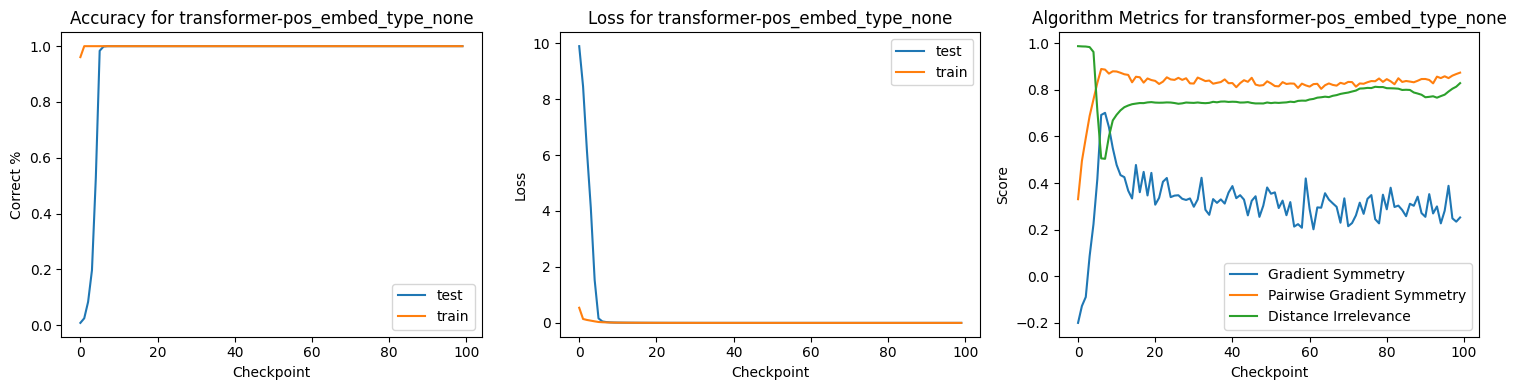

/usr/local/lib/python3.12/dist-packages/devinterp/slt/sampler.py:117: UserWarning: Using passed in nbeta. Make sure callbacks are also initialized with the same nbeta.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:240: UserWarning: You are taking more draws than burn-in steps, your LLC estimates will likely be underestimates. Please check LLC chain convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:244: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond the number dataloader batches are cycled from the start, f.e. 9 samples from [A, B, C] would be [B, A, C, B, A, C, B, A, C].)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:285: UserWarning: If you're setting a nbeta or temperature in optimiz

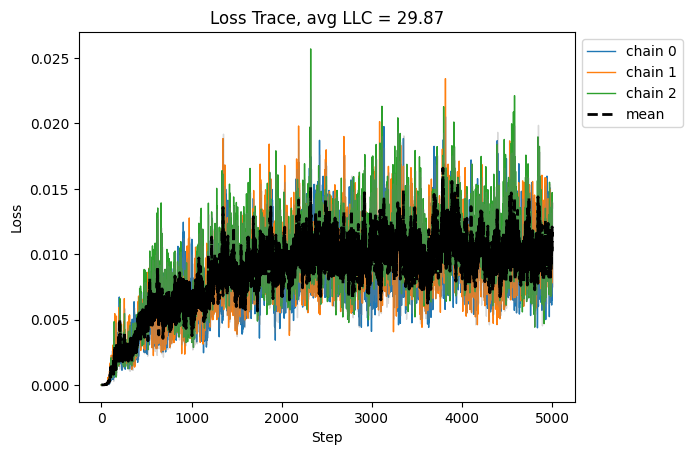

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/devinterp/slt/llc.py:109: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.llc_std = self.llc_per_chain.std()


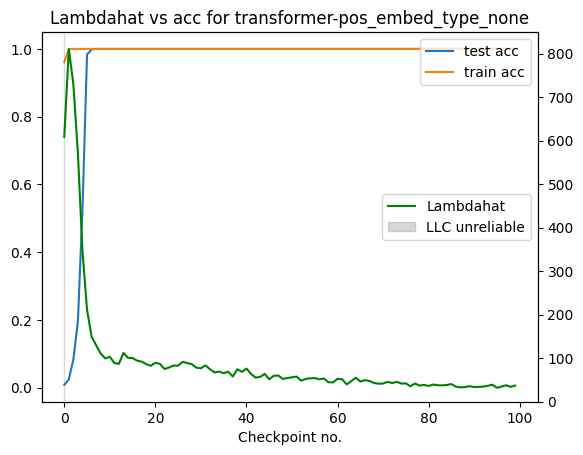

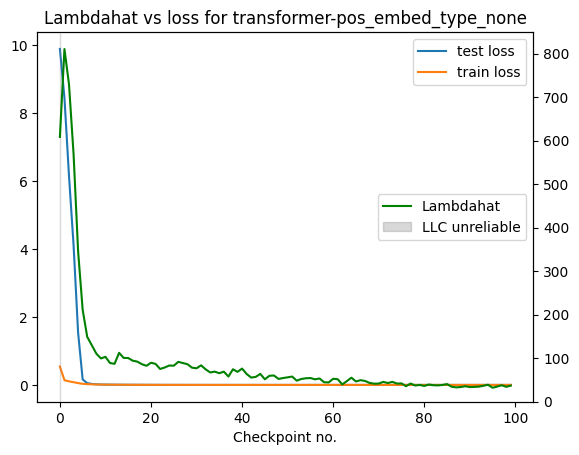

LLC results for transformer-pos_embed_type_none
Final checkpoint LLC estimate: 37.01316833496094
Minimum nonzero LLC estimate: 32.04069519042969 at checkpoint 95
Running: const_attn-pos_embed_type_none


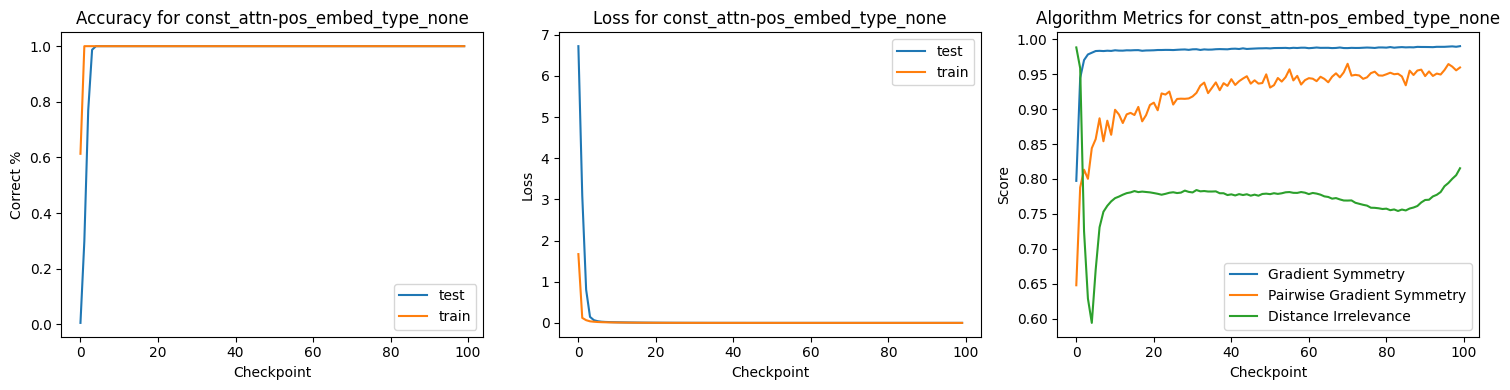

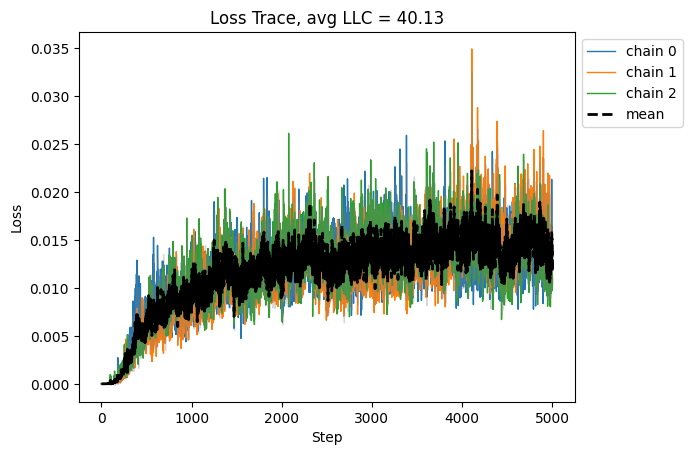

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

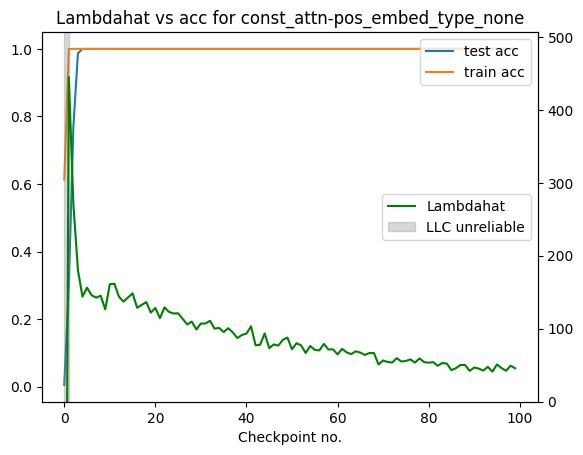

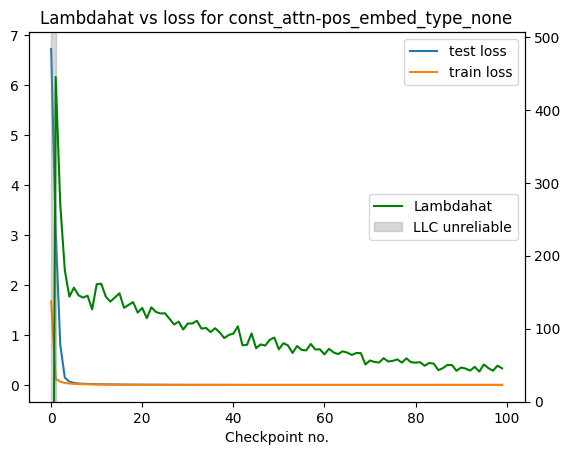

LLC results for const_attn-pos_embed_type_none
Final checkpoint LLC estimate: 45.761451721191406
Minimum nonzero LLC estimate: 41.24209976196289 at checkpoint 93
Running: transformer-d_model_32


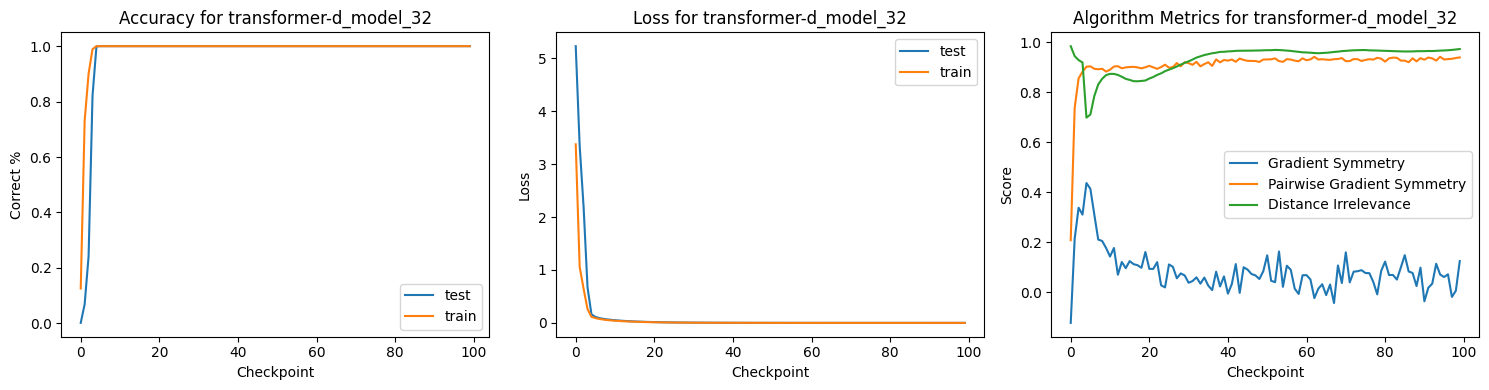

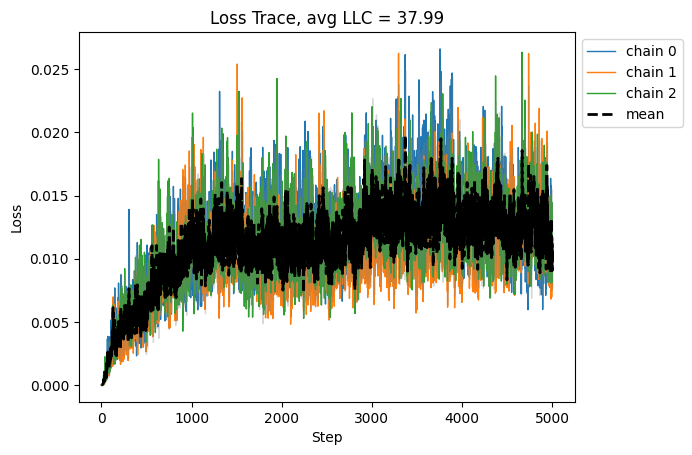

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

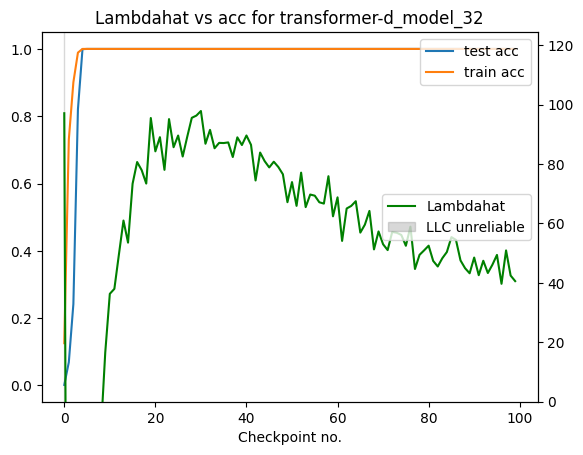

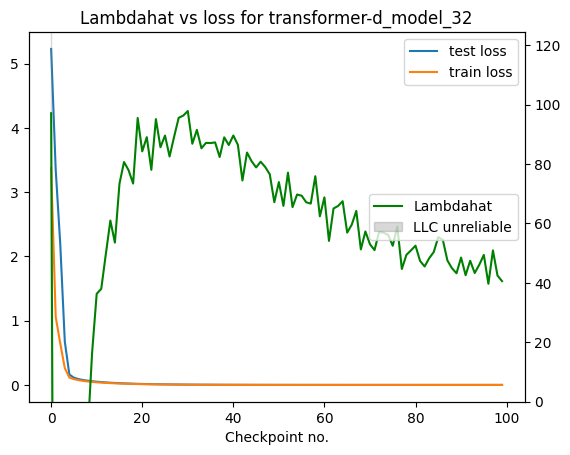

LLC results for transformer-d_model_32
Final checkpoint LLC estimate: 40.594852447509766
Minimum nonzero LLC estimate: 16.623249053955078 at checkpoint 1
Running: transformer-d_model_256


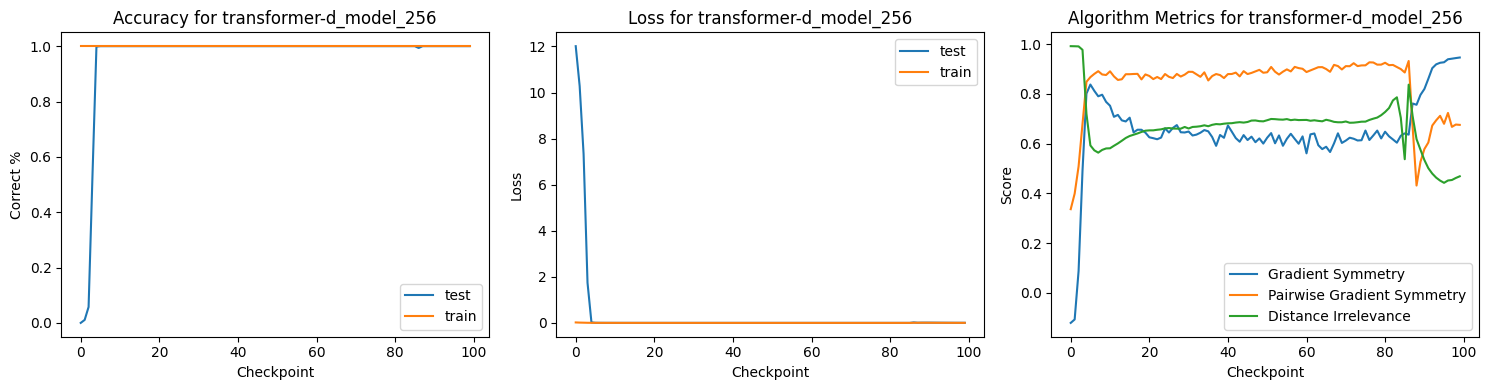

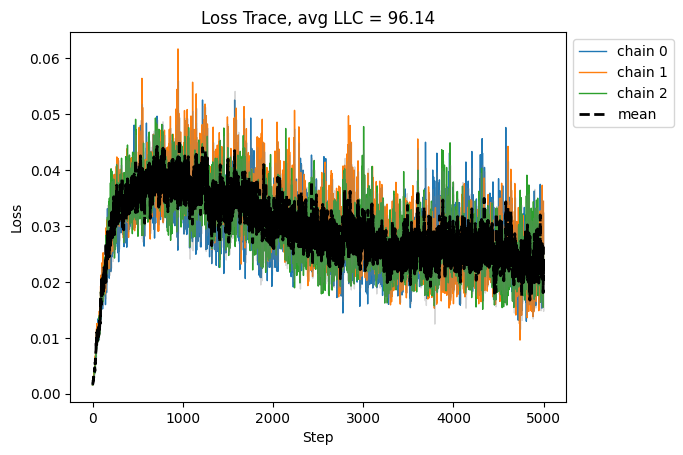

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

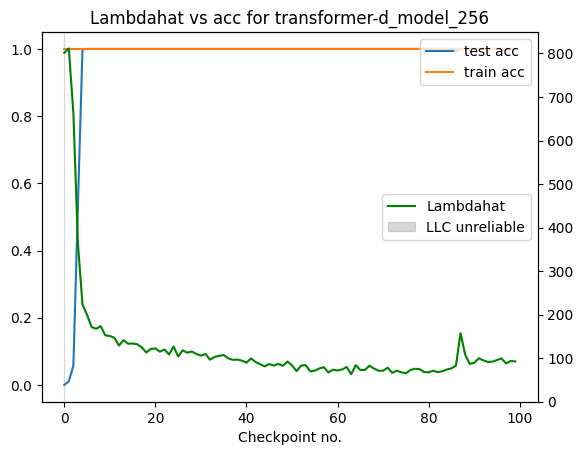

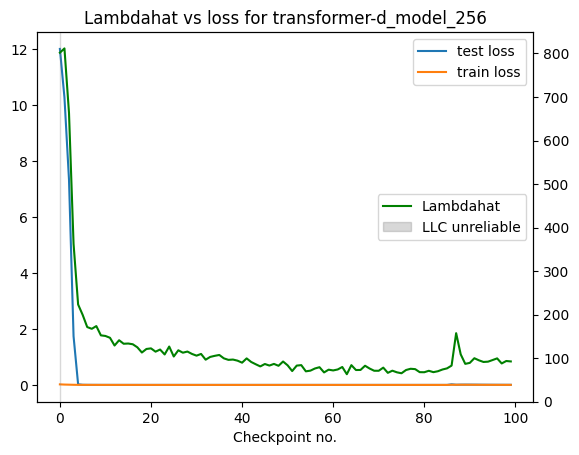

LLC results for transformer-d_model_256
Final checkpoint LLC estimate: 92.55423736572266
Minimum nonzero LLC estimate: 63.20306396484375 at checkpoint 63
Running: const_attn-d_model_32


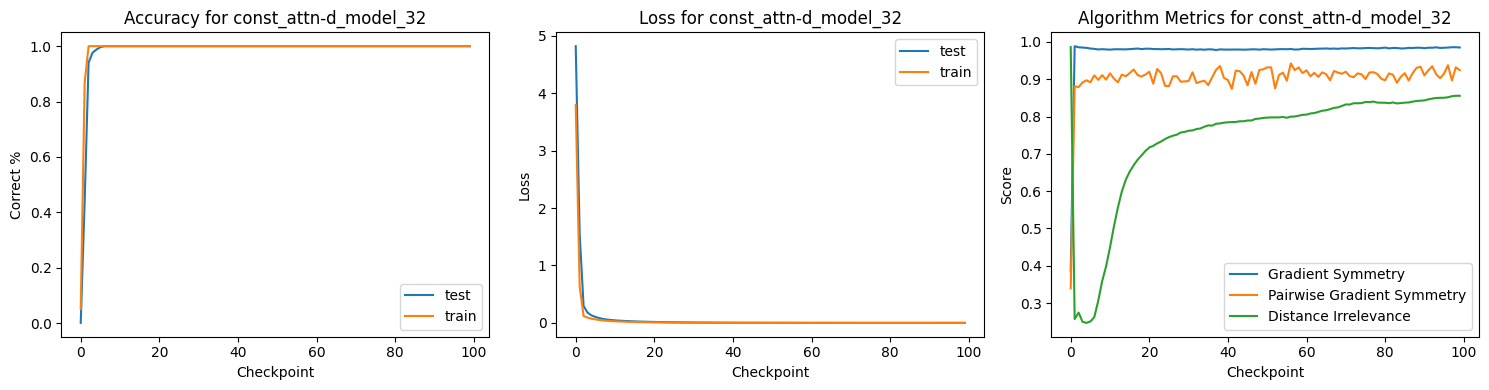

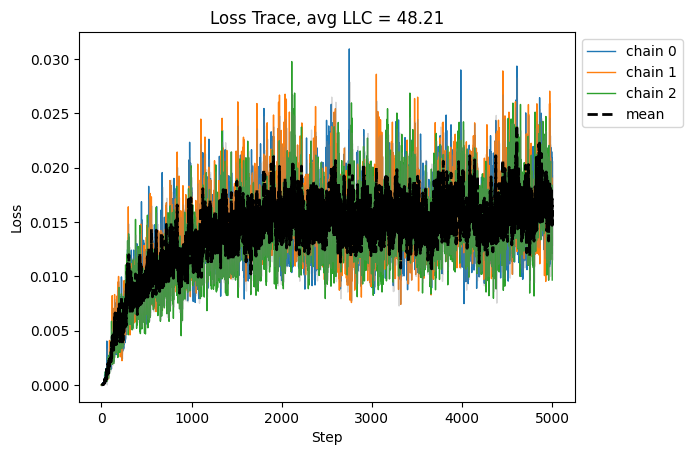

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

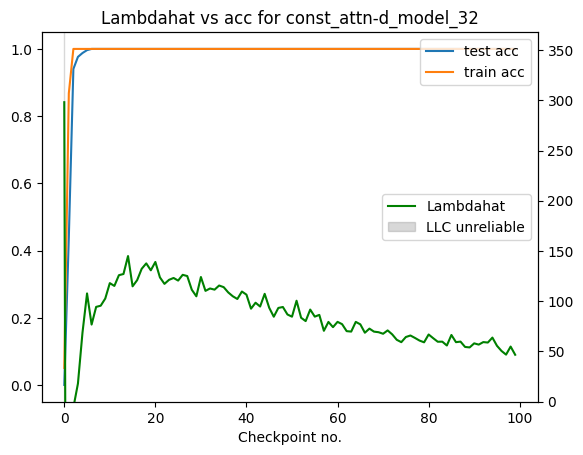

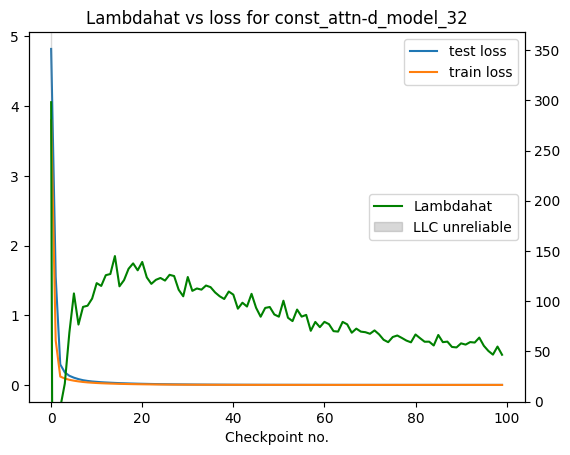

LLC results for const_attn-d_model_32
Final checkpoint LLC estimate: 46.74107360839844
Minimum nonzero LLC estimate: 18.040895462036133 at checkpoint 1
Running: const_attn-d_model_256


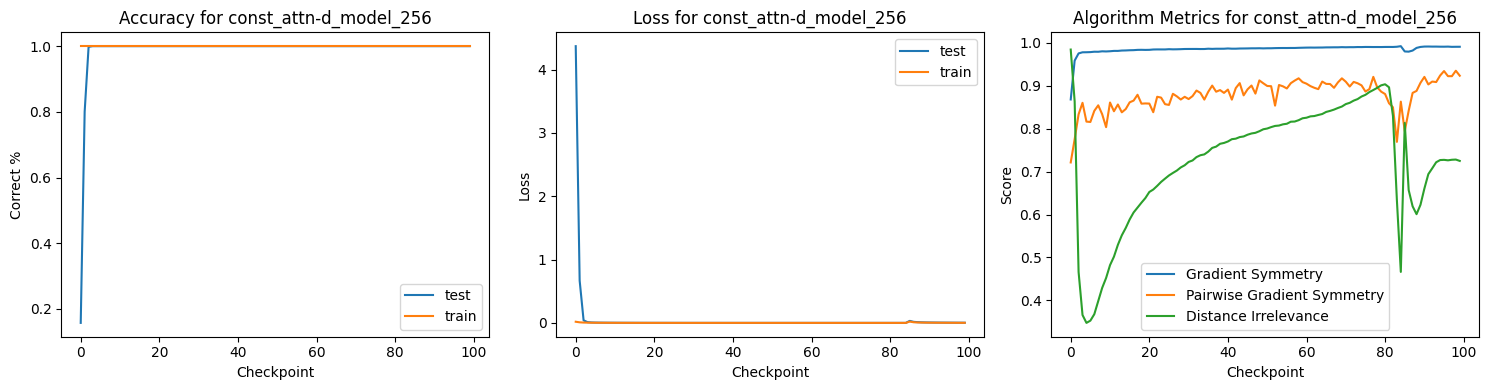

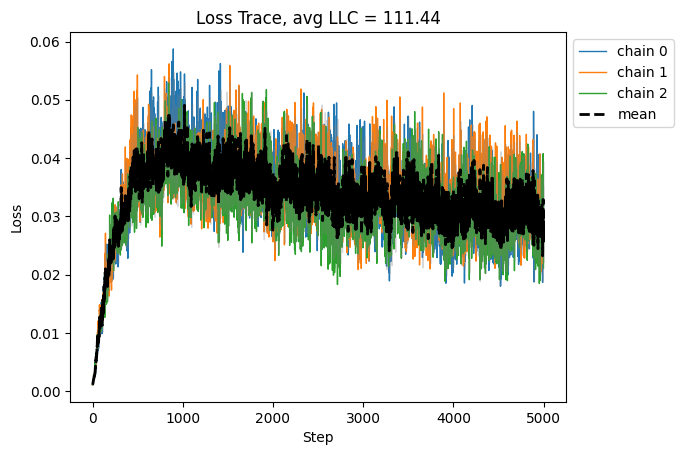

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

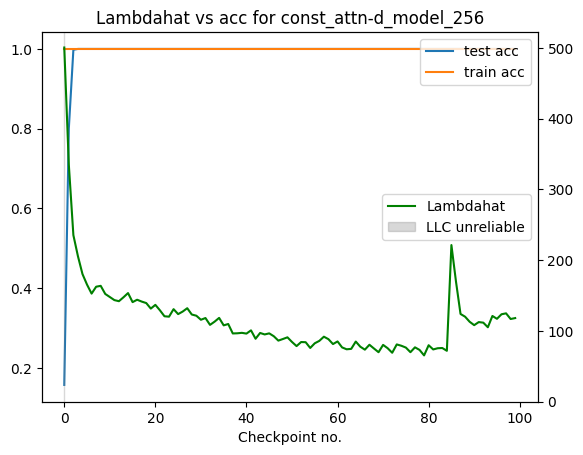

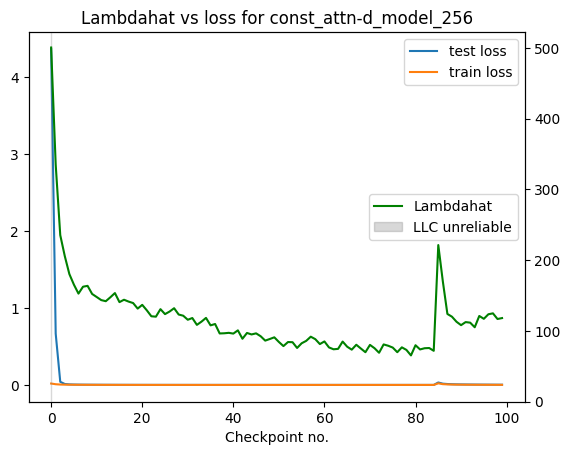

LLC results for const_attn-d_model_256
Final checkpoint LLC estimate: 118.23270416259766
Minimum nonzero LLC estimate: 65.47488403320312 at checkpoint 79
Ran 6 ablations.


In [ ]:
# Baseline configs (reference points)
TRANSFORMER_BASELINE = {
    'model': 'transformer',
    'model_type': 'transformer',
    'p': 59,
    'n_batches': 25000,
    'batch_size_or_frac': 1.0,
    'train_frac': 0.4,
    'lr': 0.001,
    'wd': 2.0,
    'd_model': 64,
    'use_constant_attn': False,
    'pos_embed_type': 'learned',
    'seed': 69,
}

CONST_ATTN_BASELINE = {
    **TRANSFORMER_BASELINE,
    'model': 'const_attn',
    'model_type': 'transformer',
    'use_constant_attn': True,
}

MLP_BASELINE = {
    'model': 'mlp',
    'model_type': 'mlp',
    'p': 59,
    'n_batches': 2500,
    'batch_size_or_frac': 1.0,
    'train_frac': 0.4,
    'lr': 0.01,
    'wd': 2.0,
    'embed_dim': 24,
    'hidden_size': 96,
    'seed': 69,
}

def make_ablation(baseline, **changes):
    """Create ablation config from baseline with specified changes."""
    config = {**baseline, **changes}
    # Generate descriptive name
    change_str = '-'.join(f"{k}_{v}" for k, v in changes.items())
    config['name'] = f"{baseline['model']}-{change_str}"
    return config

def config_to_params(config):
    """Convert config dict to experiment params object."""
    p = config['p']
    train_frac = config['train_frac']
    batch_size_or_frac = config['batch_size_or_frac']

    batch_size = batch_size_or_frac
    if batch_size_or_frac <= 1:
        batch_size = int(p * p * batch_size_or_frac * train_frac)

    if config['model'] in ['transformer', 'const_attn']:
        return TransformerExperimentParams(
            n_batches=config['n_batches'],
            lr=config['lr'],
            batch_size=batch_size,
            weight_decay=config['wd'],
            d_model=config['d_model'],
            d_mlp=4 * config['d_model'],
            use_constant_attn=config['use_constant_attn'],
            pos_embed_type=config.get('pos_embed_type', 'learned'),
            random_seed=config['seed'],
        )
    else:  # mlp
        return MlpExperimentParams(
            n_batches=config['n_batches'],
            batch_size=batch_size,
            lr=config['lr'],
            weight_decay=config['wd'],
            hidden_size=config['hidden_size'],
            embed_dim=config['embed_dim'],
            random_seed=config['seed'],
        )

# ============ ABLATION CONFIGS ============

ABLATIONS = [
    # --- PE ablation (2 runs) ---
    make_ablation(TRANSFORMER_BASELINE, pos_embed_type='none'),
    make_ablation(CONST_ATTN_BASELINE, pos_embed_type='none'),

    # --- Width ablation (4 runs: 2 transformer + 1 const + 1 mlp) ---
    make_ablation(TRANSFORMER_BASELINE, d_model=32),
    make_ablation(TRANSFORMER_BASELINE, d_model=256),
    make_ablation(CONST_ATTN_BASELINE, d_model=32),
    make_ablation(CONST_ATTN_BASELINE, d_model=256),
]

# ============ RUN SWEEP ============

def run_sweep(ablations, skip_existing=True):
    results = []
    for config in ablations:
        print(f"Running: {config['name']}")
        params = config_to_params(config)
        runId = config['name']
        torch.manual_seed(params.random_seed)

        dataset = make_dataset(params.p)
        train_data, test_data = train_test_split(dataset, params.train_frac, params.random_seed)

        all_checkpointed_models, df = train(
            train_dataset=train_data, test_dataset=test_data, all_data=dataset, params=params, model_type=config['model_type'], verbose=False
        )
        save_plots(all_checkpointed_models, df, config['name'])
        model_llc_params = LlcEstimationParams(batch_size=params.batch_size, nbeta=len(dataset))
        compute_and_plot_llc_loss_trace(all_checkpointed_models, df, config['name'], model_llc_params, train_data)
        model_llcs = compute_llc(all_checkpointed_models, df, config['name'], model_llc_params, train_data)
        plot_llcs(all_checkpointed_models, df, config['name'], model_llcs)
        results.append((df, model_llcs))
        print("LLC results for", runId)
        print("Final checkpoint LLC estimate:", model_llcs[-1]["llc/mean"])
        min_llc, min_idx = min((v, i) for (i, v) in enumerate([llc["llc/mean"] for llc in model_llcs if llc["llc/mean"] > 0]))
        print("Minimum nonzero LLC estimate:", min_llc, "at checkpoint", min_idx)
    return results

train_results = run_sweep(ABLATIONS)
print(f"Ran {len(train_results)} ablations.")
